In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ==== Config ====
IMAGE_SIZE = 64
NUM_CLASSES = 29
PATCH_SIZE = 8
EMBED_DIM = 64
NUM_HEADS = 2
MLP_DIM = 128
NUM_LAYERS = 4
BATCH_SIZE = 64
EPOCHS = 30

# ==== Data ====
train_dir = r"E:\cnndatasets\train"  # update this
val_dir = r"E:\cnndatasets\val"      # update this

train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=10, zoom_range=0.1)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(train_dir, target_size=(IMAGE_SIZE, IMAGE_SIZE), batch_size=BATCH_SIZE, class_mode='categorical')
val_gen = val_datagen.flow_from_directory(val_dir, target_size=(IMAGE_SIZE, IMAGE_SIZE), batch_size=BATCH_SIZE, class_mode='categorical')

# ==== Patch Embedding ====
class PatchEmbedding(layers.Layer):
    def __init__(self, patch_size=8, embed_dim=64):
        super().__init__()
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.proj = layers.Conv2D(filters=embed_dim, kernel_size=(patch_size, patch_size), strides=(patch_size, patch_size), padding='valid')
        self.flatten = layers.Reshape((-1, embed_dim))

    def build(self, input_shape):
        num_patches = (input_shape[1] // self.patch_size) * (input_shape[2] // self.patch_size)
        self.pos_emb = self.add_weight("pos_emb", shape=(1, num_patches, self.embed_dim), initializer="random_normal")

    def call(self, x):
        x = self.proj(x)
        x = self.flatten(x)
        return x + self.pos_emb

# ==== Transformer Encoder ====
def transformer_encoder(x, embed_dim, num_heads, mlp_dim):
    # Multi-head Self Attention
    x1 = layers.LayerNormalization()(x)
    attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(x1, x1)
    x2 = layers.Add()([x, attn])
    
    # MLP
    x3 = layers.LayerNormalization()(x2)
    mlp = layers.Dense(mlp_dim, activation='gelu')(x3)
    mlp = layers.Dense(embed_dim)(mlp)
    return layers.Add()([x2, mlp])

# ==== Build Lightweight ViT ====
def build_vit():
    inputs = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    x = PatchEmbedding(patch_size=PATCH_SIZE, embed_dim=EMBED_DIM)(inputs)

    for _ in range(NUM_LAYERS):
        x = transformer_encoder(x, EMBED_DIM, NUM_HEADS, MLP_DIM)

    x = layers.LayerNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(MLP_DIM, activation='gelu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    return models.Model(inputs, outputs)

model = build_vit()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# ==== Callbacks ====
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, min_lr=1e-6),
    # Use .h5 to avoid .keras format errors
    ModelCheckpoint("vit_light_model_best_222.h5", monitor='val_accuracy', save_best_only=True, verbose=1)
]

# ==== Train ====
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)


Found 115364 images belonging to 29 classes.
Found 28830 images belonging to 29 classes.
Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 64, 64, 3)]          0         []                            
                                                                                                  
 patch_embedding_2 (PatchEm  (None, 64, 64)               16448     ['input_3[0][0]']             
 bedding)                                                                                         
                                                                                                  
 layer_normalization_4 (Lay  (None, 64, 64)               128       ['patch_embedding_2[0][0]']   
 erNormalization)                                                                                 
   

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1803/1803 [==============================] - 2150s 1s/step - loss: 1.1391 - accuracy: 0.6602 - val_loss: 0.5898 - val_accuracy: 0.8225 - lr: 0.0010
Epoch 2/30
1803/1803 [==============================] - ETA: 0s - loss: 0.5566 - accuracy: 0.8339
Epoch 2: val_accuracy improved from 0.82251 to 0.86320, saving model to vit_light_model_best_222.h5
1803/1803 [==============================] - 1333s 739ms/step - loss: 0.5566 - accuracy: 0.8339 - val_loss: 0.4400 - val_accuracy: 0.8632 - lr: 0.0010
Epoch 3/30
1803/1803 [==============================] - ETA: 0s - loss: 0.4256 - accuracy: 0.8748
Epoch 3: val_accuracy improved from 0.86320 to 0.88672, saving model to vit_light_model_best_222.h5
1803/1803 [==============================] - 967s 536ms/step - loss: 0.4256 - accuracy: 0.8748 - val_loss: 0.3887 - val_accuracy: 0.8867 - lr: 0.0010
Epoch 4/30
1803/1803 [==============================] - ETA: 0s - loss: 0.3648 - accuracy: 0.8939
Epoch 4: val_accuracy improved from 0.88672 to 0.91270, s

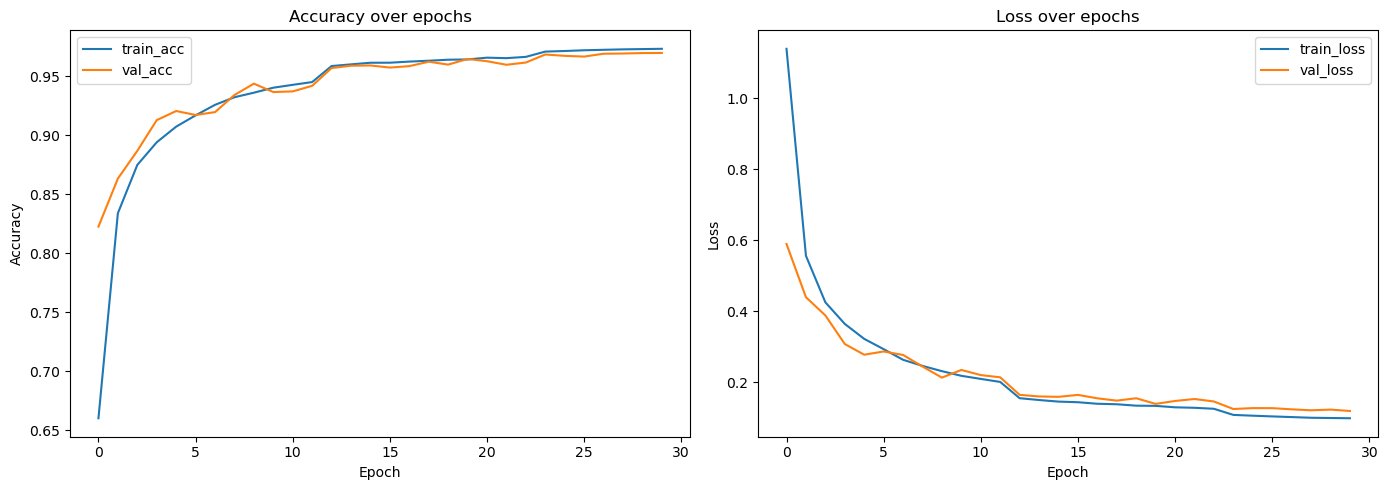

451/451 [==============================] - 80s 176ms/step

Classification Report:

              precision    recall  f1-score   support

           ا       0.99      0.99      0.99      1000
           ب       0.97      0.96      0.97      1000
           ت       0.95      0.97      0.96      1000
           ث       0.92      0.93      0.93       897
           ج       0.99      0.97      0.98       944
           ح       0.95      0.99      0.97       628
           خ       0.94      0.97      0.95       775
           د       0.99      0.96      0.98      1000
           ذ       0.98      0.98      0.98      1000
           ر       0.98      0.98      0.98      1000
           ز       0.99      0.98      0.98      1000
           س       0.96      0.94      0.95      1000
           ش       0.99      0.95      0.97      1000
           ص       0.99      0.97      0.98      1000
           ض       0.98      0.97      0.97      1000
           ط       0.93      0.96      0.94      100

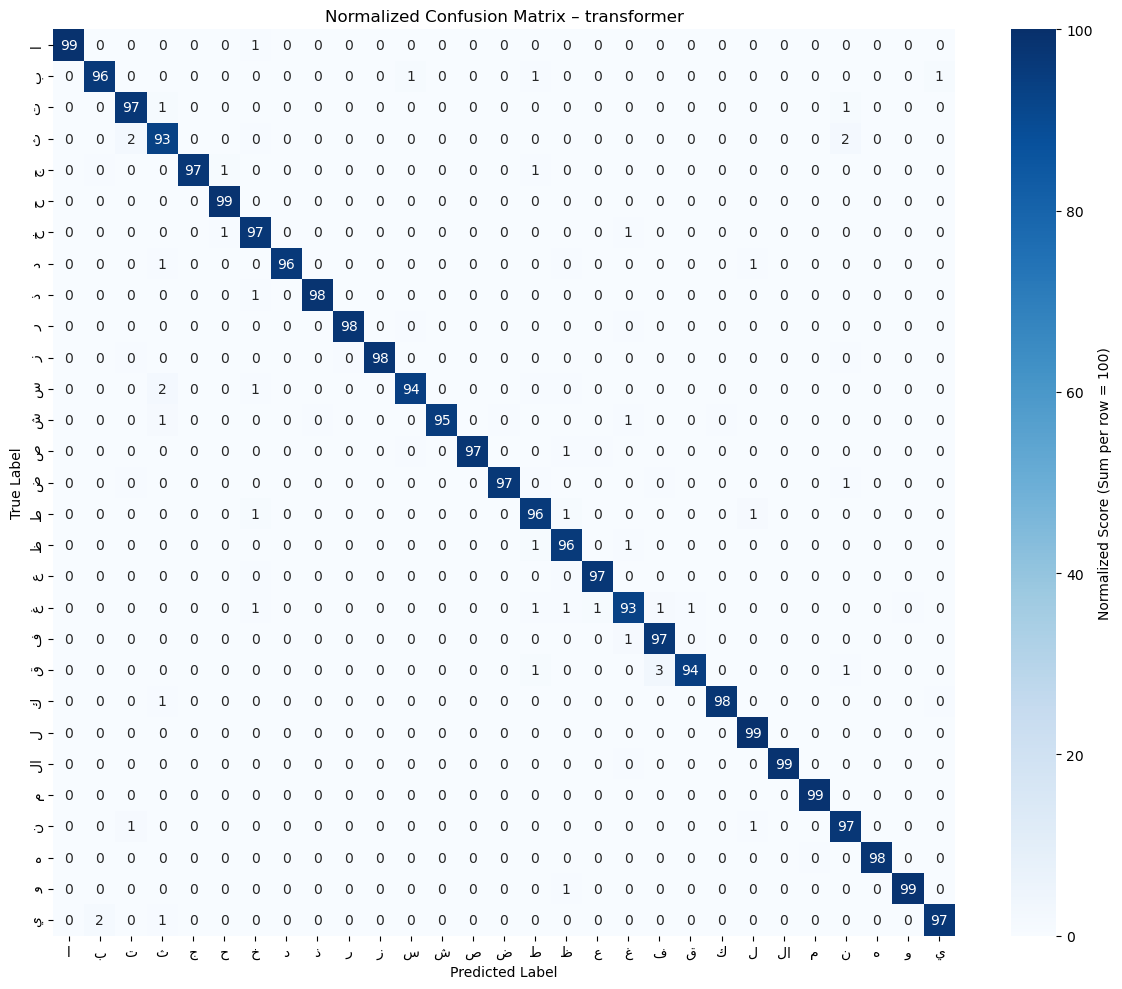

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.utils import plot_model
import io
import textwrap

# --- 1. Plot training history ---
def plot_training_history(history):
    plt.figure(figsize=(14,5))

    # Accuracy plot
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='train_acc')
    plt.plot(history.history['val_accuracy'], label='val_acc')
    plt.title('Accuracy over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss plot
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title('Loss over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.savefig('training_history222.png', dpi=300)
    plt.show()

plot_training_history(history)

# --- 2. Save model architecture image ---
plot_model(model, to_file='model_structure222.png', show_shapes=True, show_layer_names=True)

# --- 3. Save model summary as image ---
def save_model_summary_as_image(model, filename='model_summary222.png'):
    stream = io.StringIO()
    model.summary(print_fn=lambda x: stream.write(x + '\n'))
    summary_str = stream.getvalue()
    stream.close()

    # Wrap long lines
    summary_str_wrapped = '\n'.join(textwrap.wrap(summary_str, width=120))

    plt.figure(figsize=(12, len(summary_str_wrapped.split('\n'))*0.3))
    plt.text(0, 1, summary_str_wrapped, fontfamily='monospace', fontsize=8, verticalalignment='top')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.close()

save_model_summary_as_image(model)

# --- 4. Prepare labels ---
class_labels = list(val_gen.class_indices.keys())

# --- 5. Predict on validation set ---
val_gen.reset()
y_pred_probs = model.predict(val_gen, verbose=1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = val_gen.classes

# --- 6. Print classification report and metrics ---
report_dict = classification_report(y_true, y_pred_classes, target_names=class_labels, output_dict=True)
report_text = classification_report(y_true, y_pred_classes, target_names=class_labels)

print("\nClassification Report:\n")
print(report_text)

acc = accuracy_score(y_true, y_pred_classes)
precision = precision_score(y_true, y_pred_classes, average='weighted')
recall = recall_score(y_true, y_pred_classes, average='weighted')
f1 = f1_score(y_true, y_pred_classes, average='weighted')

print(f"Overall Accuracy: {acc:.4f}")
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-score: {f1:.4f}")

# --- 7. Save classification report as image ---
def save_classification_report_as_image(report_str, filename='classification_report222.png'):
    lines = report_str.split('\n')
    plt.figure(figsize=(10, len(lines)*0.3))
    y = 1
    for line in lines:
        plt.text(0, y, line, fontfamily='monospace', fontsize=8, verticalalignment='top')
        y -= 0.04
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.close()

save_classification_report_as_image(report_text)

# --- 8. Plot normalized confusion matrix (row-wise %), save figure ---
cm = confusion_matrix(y_true, y_pred_classes)
cm_scaled = (cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]) * 100  # Normalize rows to sum=100%

plt.figure(figsize=(12, 10))
sns.heatmap(cm_scaled, annot=True, fmt='.0f', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            vmin=0, vmax=100,
            cbar_kws={'label': 'Normalized Score (Sum per row = 100)'})
plt.title('Normalized Confusion Matrix – transformer')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('transformer_confusion_matrix222.png', dpi=300)
plt.show()
